In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("TensorFlow Version:", tf.__version__)

2026-05-27 04:21:29.052944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779855689.240061      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779855689.291342      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779855689.722361      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779855689.722400      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779855689.722403      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [3]:
IMG_SIZE=(224,224)

BATCH_SIZE=32

EPOCHS=10

SEED=42

DATASET_PATH="/kaggle/input/datasets/ebinbijuabraham/indian-sign-language-dataset/Indian"

In [4]:
dataset=tf.keras.utils.image_dataset_from_directory(

    DATASET_PATH,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)

class_names=dataset.class_names

print(class_names)

print("Number of classes:",len(class_names))

Found 42745 files belonging to 35 classes.


I0000 00:00:1779855754.209648      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779855754.215466      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes: 35


In [5]:
dataset_size=len(dataset)

train_size=int(0.70*dataset_size)

val_size=int(0.15*dataset_size)

test_size=int(0.15*dataset_size)

train_dataset=dataset.take(train_size)

remaining=dataset.skip(train_size)

val_dataset=remaining.take(val_size)

test_dataset=remaining.skip(val_size)

print("Training batches:",len(train_dataset))

print("Validation batches:",len(val_dataset))

print("Testing batches:",len(test_dataset))

Training batches: 935
Validation batches: 200
Testing batches: 201


In [6]:
AUTOTUNE=tf.data.AUTOTUNE

train_dataset=train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

val_dataset=val_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset=test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

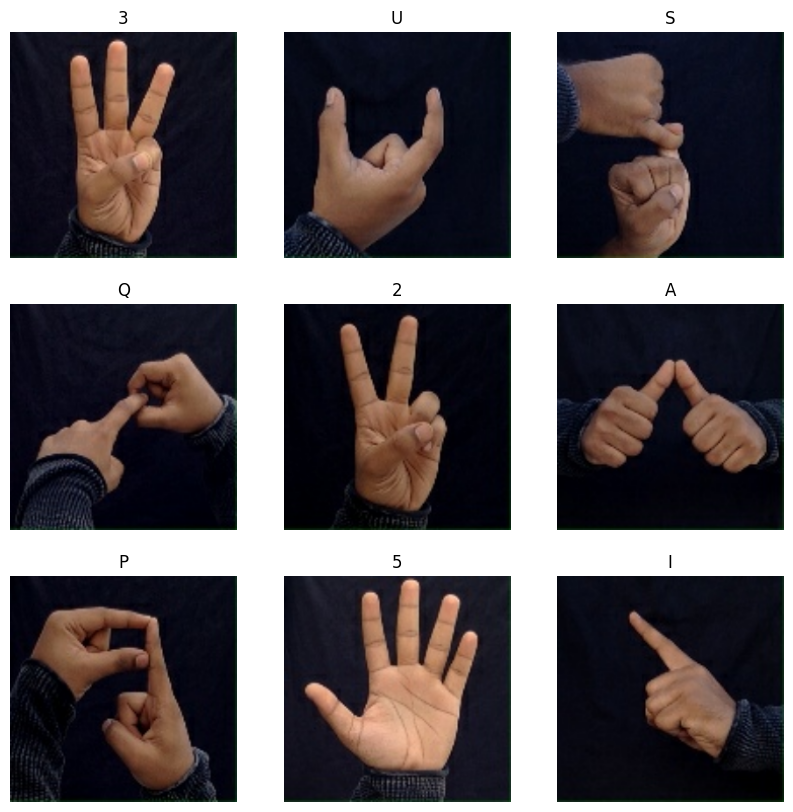

In [7]:
plt.figure(figsize=(10,10))

for images,labels in train_dataset.take(1):

    for i in range(9):

        ax=plt.subplot(3,3,i+1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.show()

In [8]:
base_model=MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights='imagenet'
)

base_model.trainable=False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
preprocess=tf.keras.applications.mobilenet_v2.preprocess_input

inputs=keras.Input(
    shape=(224,224,3)
)

x=preprocess(inputs)

x=base_model(
    x,
    training=False
)

x=layers.GlobalAveragePooling2D()(x)

x=layers.Dropout(0.3)(x)

outputs=layers.Dense(

    len(class_names),

    activation='softmax'

)(x)

model=keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 35)             │        44,835 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,302,819 (8.78 MB)

 Trainable params: 44,835 (175.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [11]:
callbacks=[

    keras.callbacks.EarlyStopping(

        patience=3,

        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(

        patience=2,

        factor=0.2
    )
]

In [12]:
history=model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=callbacks
)

Epoch 1/10


I0000 00:00:1779855762.603072     168 service.cc:152] XLA service 0x7f23e40084e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779855762.603106     168 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779855762.603110     168 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779855763.648987     168 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-27 04:22:52.381877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 04:22:52.519094: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1779855774.510650     168 device_co

935/935 ━━━━━━━━━━━━━━━━━━━━ 98s 87ms/step - accuracy: 0.8966 - loss: 0.4951 - val_accuracy: 1.0000 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 2/10
935/935 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.9999 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 7.7197e-04 - learning_rate: 0.0010
Epoch 3/10
935/935 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 3.5990e-04 - learning_rate: 0.0010
Epoch 4/10
935/935 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 1.0000 - loss: 5.6089e-04 - val_accuracy: 1.0000 - val_loss: 1.8590e-04 - learning_rate: 0.0010
Epoch 5/10
935/935 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 1.0000 - loss: 3.3339e-04 - val_accuracy: 1.0000 - val_loss: 1.0343e-04 - learning_rate: 0.0010
Epoch 6/10
935/935 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 1.0000 - loss: 1.7412e-04 - val_accuracy: 1.0000 - val_loss: 6.7821e-05 - learning_rate: 0.0010
Epoch 7/10
935/935 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step -

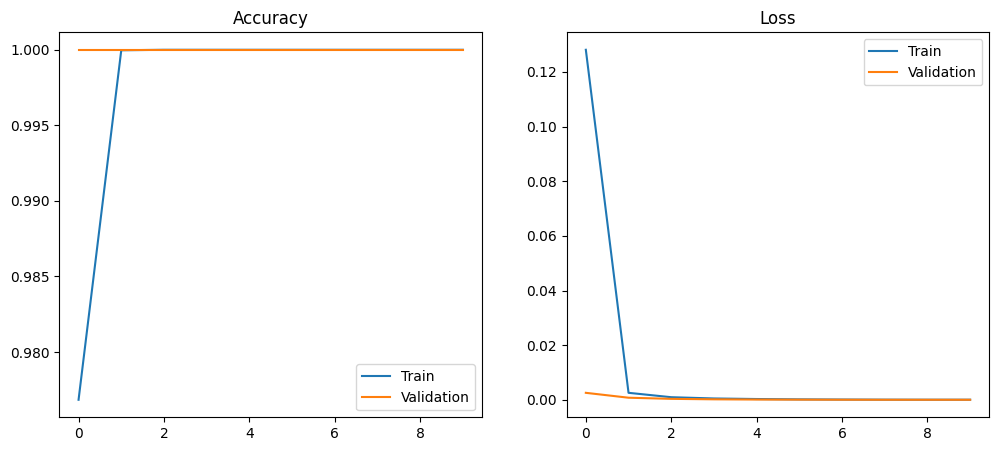

In [13]:
acc=history.history['accuracy']

val_acc=history.history['val_accuracy']

loss=history.history['loss']

val_loss=history.history['val_loss']

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.plot(acc)

plt.plot(val_acc)

plt.legend(
['Train','Validation']
)

plt.title("Accuracy")


plt.subplot(1,2,2)

plt.plot(loss)

plt.plot(val_loss)

plt.legend(
['Train','Validation']
)

plt.title("Loss")

plt.show()

In [14]:
test_loss,test_accuracy=\
model.evaluate(test_dataset)

print(
    "Final Test Accuracy:",
    test_accuracy*100
)

print(
    "Final Test Loss:",
    test_loss
)

200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 1.4538e-05

2026-05-27 04:31:28.022372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 04:31:28.180096: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 04:31:28.317993: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


201/201 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - accuracy: 1.0000 - loss: 1.4544e-05
Final Test Accuracy: 100.0
Final Test Loss: 1.5085502127476502e-05


In [15]:
y_true=[]

y_pred=[]

for images,labels in test_dataset:

    predictions=model.predict(images)

    predicted=np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━

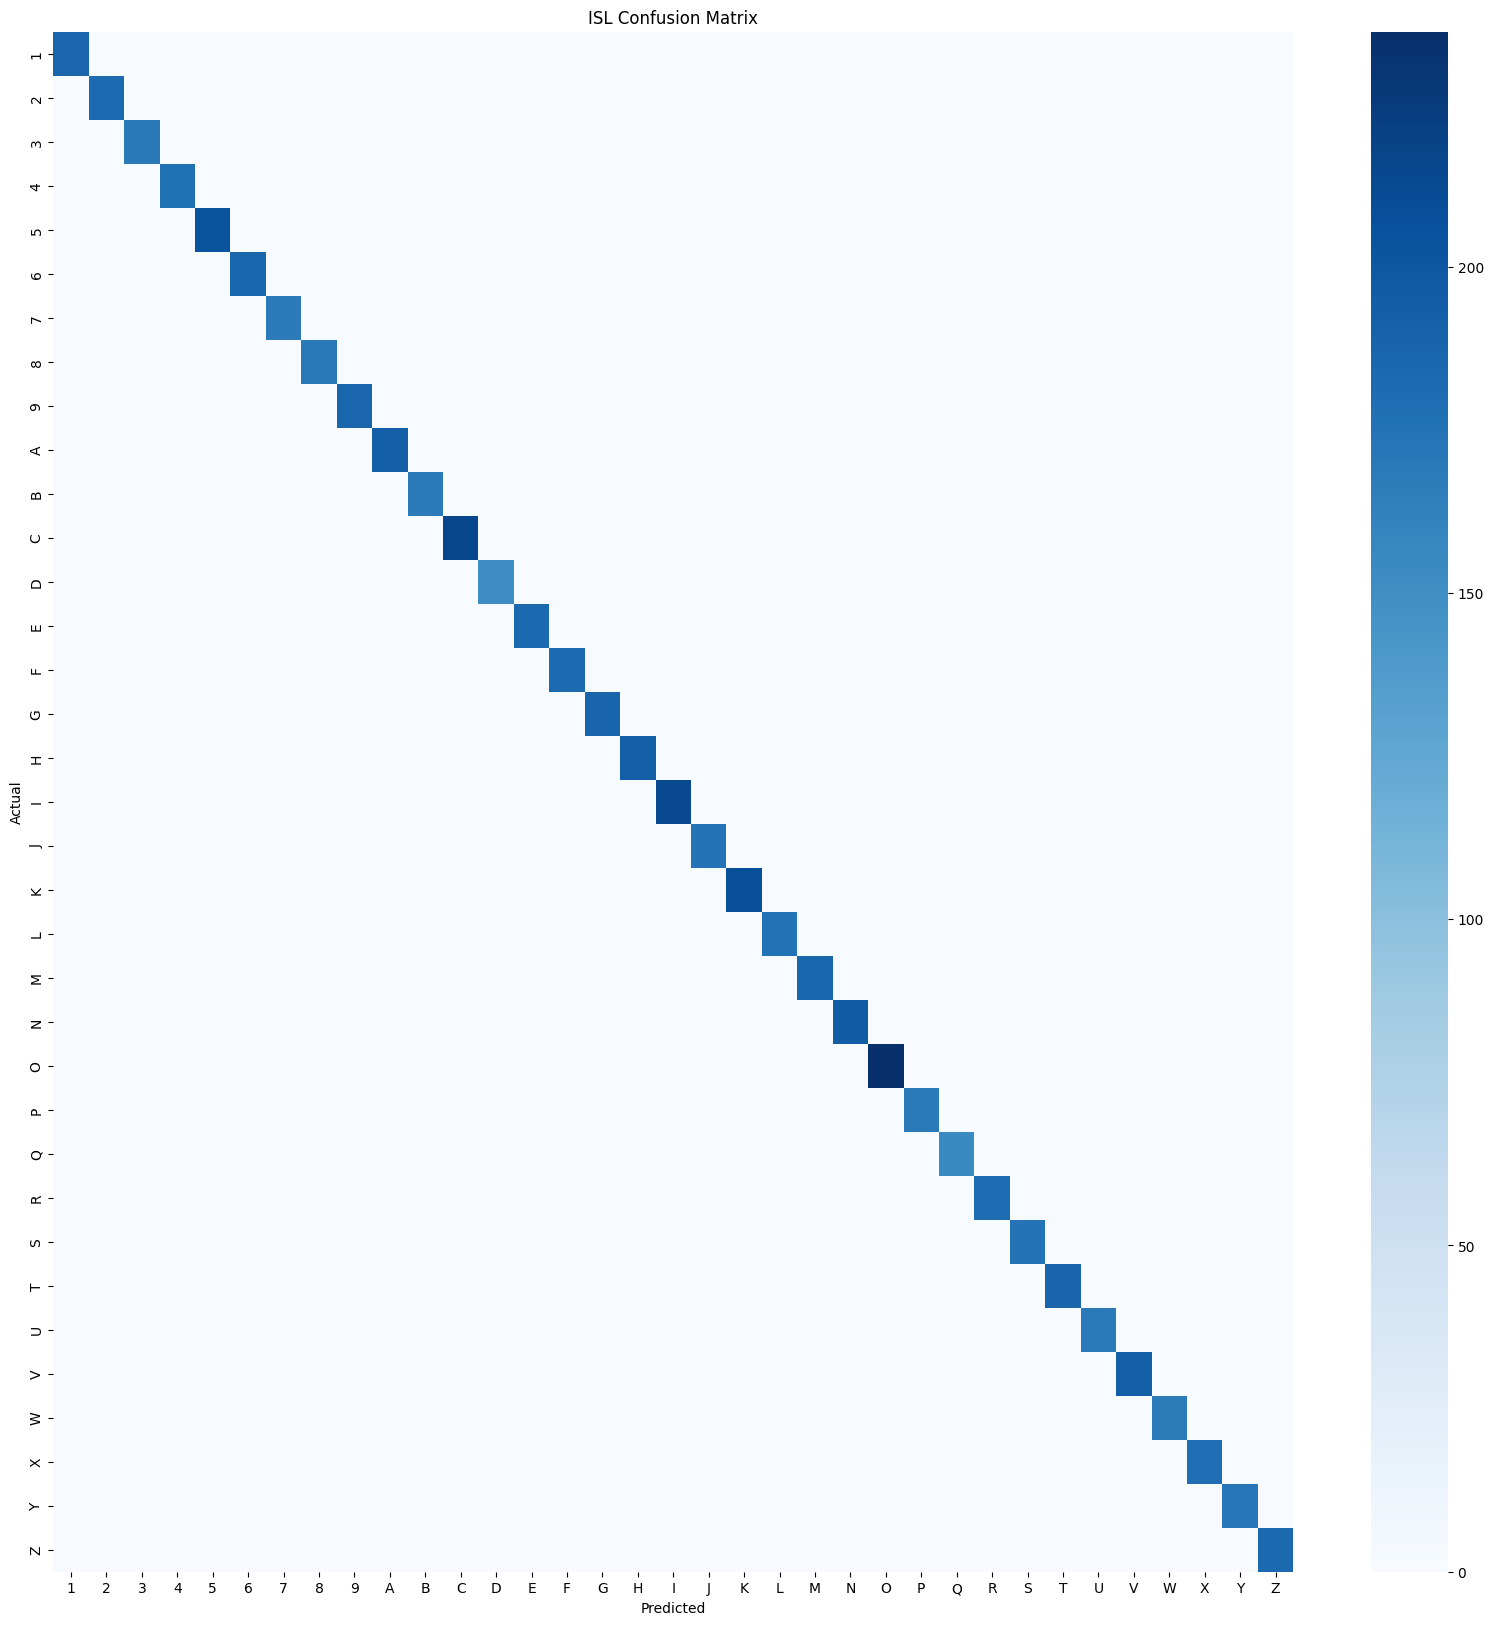

In [16]:
cm=confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(20,20)
)

sns.heatmap(

    cm,

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
"ISL Confusion Matrix"
)

plt.show()

In [17]:
print(

classification_report(

    y_true,

    y_pred,

    target_names=class_names
)

)

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       187
           2       1.00      1.00      1.00       183
           3       1.00      1.00      1.00       170
           4       1.00      1.00      1.00       177
           5       1.00      1.00      1.00       203
           6       1.00      1.00      1.00       186
           7       1.00      1.00      1.00       168
           8       1.00      1.00      1.00       170
           9       1.00      1.00      1.00       187
           A       1.00      1.00      1.00       193
           B       1.00      1.00      1.00       168
           C       1.00      1.00      1.00       216
           D       1.00      1.00      1.00       152
           E       1.00      1.00      1.00       184
           F       1.00      1.00      1.00       182
           G       1.00      1.00      1.00       188
           H       1.00      1.00      1.00       192
           I       1.00    

In [18]:
model.save(
"/kaggle/working/ISL_Model.h5"
)

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
 model.save("/kaggle/working/ISL_Model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
import os

print(os.listdir("/kaggle/working"))

['ISL_Model.h5', '.virtual_documents']
